In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tracklab import ExperimentReader

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot Configs

In [2]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code

In [123]:
experiment_name = 'sanity_check'
base_dir = "../data/"
n_artifacts_plot = 7
reader = ExperimentReader(experiment_name, base_dir=base_dir)
table = reader.runs_table(results=True)

run_id = reader.list_runs()[-1]
cfg = reader.load_config(run_id)
logit_positions = cfg['extra_args']['logit_positions']
mu_idx = 2
print(f"Logit positions: {logit_positions}, evaluation index: {mu_idx}")

metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()


logit_list = reader.list_artifacts(run_id,group='logits')
n_artifact_steps = len(logit_list)
time_indexes = np.linspace(0,n_artifact_steps-1,n_artifacts_plot).astype(int)

logits_results = {}
for time_idx in time_indexes:
    file = logit_list.iloc[time_idx]['file']
    time_step = logit_list.iloc[time_idx]['step']
    logits_data = reader.load_artifact(run_id, file,group='logits')
    raw_lists = {}
    vmin , vmax = np.inf, -np.inf
    for key in ['on','off']:
        raw_lists[key] = logits_data[key][mu_idx].flatten()
        print(f'{key}, time step: {time_step}, len: {len(raw_lists[key])}')
        vmin = min(vmin, np.min(logits_data[key][mu_idx]))
        vmax = max(vmax, np.max(logits_data[key][mu_idx]))

    logits_results[time_step] = {}
    for key in ['on','off']:
        hist, bin_edges = np.histogram(raw_lists[key], bins=80, range=(vmin,vmax), density=True)
        logits_results[time_step][key] = hist
    logits_results[time_step]['edges'] = bin_edges

Logit positions: [0.5, 0.75, 1.0], evaluation index: 2
on, time step: 0, len: 2662
off, time step: 0, len: 338074
on, time step: 526, len: 2662
off, time step: 526, len: 338074
on, time step: 1579, len: 2662
off, time step: 1579, len: 338074
on, time step: 2632, len: 2662
off, time step: 2632, len: 338074
on, time step: 3158, len: 2662
off, time step: 3158, len: 338074
on, time step: 4211, len: 2662
off, time step: 4211, len: 338074
on, time step: 5263, len: 2662
off, time step: 5263, len: 338074


In [88]:
reader.load_artifact(run_id, file,group='logits')['off'][-1].shape

(926, 127)

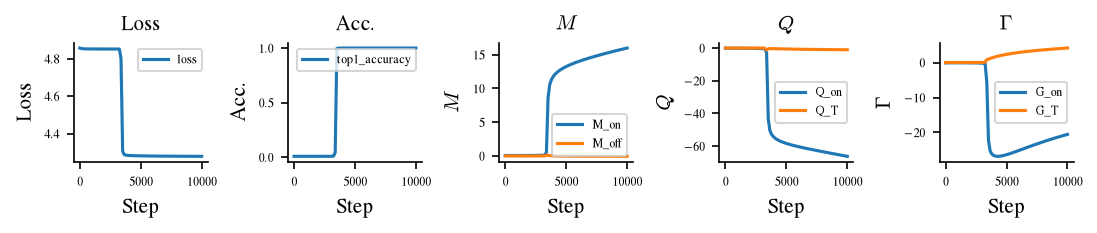

In [119]:
vars_to_plot = {
    'Loss': ['loss'],
    'Acc.': ['top1_accuracy'],
    r'$M$': ['M_on','M_off'],
    r'$Q$': ['Q_on','Q_T'],
    r'$\Gamma$': ['G_on','G_T']
}

fig , axes = create_fig(ncols=len(vars_to_plot),size='double',h=0.2)

for i, (var_name, var_cols) in enumerate(vars_to_plot.items()):
    ax = axes[i] if len(vars_to_plot) > 1 else axes
    for col in var_cols:
        ax.plot(metrics['step'], metrics[col], label=col)
    ax.set_title(var_name)
    ax.set_xlabel('Step')
    ax.set_ylabel(var_name)
    ax.legend()

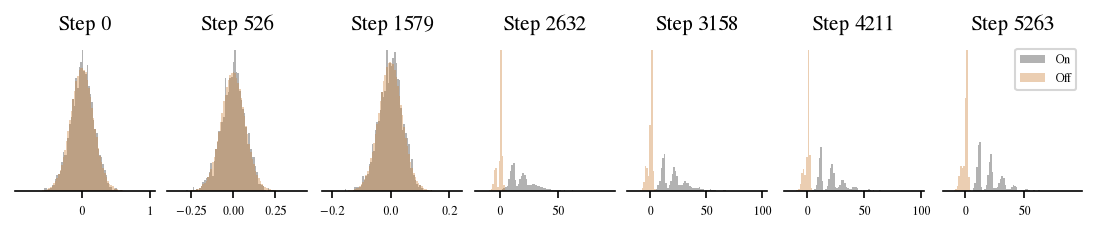

In [124]:
fig , axes = create_fig(ncols=n_artifacts_plot,size='double',h=0.2,sharex=False)

for i , (time_step, logits_data) in enumerate(logits_results.items()):
    ax = axes[i] 
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    on , off , edges = logits_data['on'], logits_data['off'], logits_data['edges']
    ax.bar(edges[:-1], on, width=np.diff(edges), alpha=0.6, label='On', color='gray', align='edge')
    ax.bar(edges[:-1], off, width=np.diff(edges), alpha=0.4, label='Off', color='peru', align='edge')
    ax.set_title(f'Step {time_step}')
    # ax.set_yscale('log')
ax.legend()